In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
folder_path = '/content/drive/MyDrive/MAJOR_PROJECT/'
os.makedirs(folder_path, exist_ok=True)

In [ ]:
notebook_source = '/content/drive/MyDrive/Colab Notebooks/3_PaDEL_Descriptor.ipynb'
notebook_dest = os.path.join(folder_path, 'L_Project/3_PaDEL_Descriptor.ipynb')

!cp "{notebook_source}" "{notebook_dest}"
print(f"Notebook saved to: {notebook_dest}")

In [3]:
import pandas as pd
features = pd.read_csv('/content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/descriptors_output.csv')
regression = pd.read_csv('/content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/regression_model.csv')

merged = pd.concat([features, regression], axis=1)
threshold = 5.7
merged["Activity"] = merged["True_pIC50"].apply(lambda x: 1 if x >= threshold else 0)
merged.to_csv('/content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/classification_ready.csv', index=False)

# Only Baseline

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv('/content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/classification_ready.csv')
print("Dataset Loaded Successfully!")
print("Shape:", data.shape)
print("Columns:", list(data.columns))

Dataset Loaded Successfully!
Shape: (207, 885)
Columns: ['PubchemFP0', 'PubchemFP1', 'PubchemFP2', 'PubchemFP3', 'PubchemFP4', 'PubchemFP5', 'PubchemFP6', 'PubchemFP7', 'PubchemFP8', 'PubchemFP9', 'PubchemFP10', 'PubchemFP11', 'PubchemFP12', 'PubchemFP13', 'PubchemFP14', 'PubchemFP15', 'PubchemFP16', 'PubchemFP17', 'PubchemFP18', 'PubchemFP19', 'PubchemFP20', 'PubchemFP21', 'PubchemFP22', 'PubchemFP23', 'PubchemFP24', 'PubchemFP25', 'PubchemFP26', 'PubchemFP27', 'PubchemFP28', 'PubchemFP29', 'PubchemFP30', 'PubchemFP31', 'PubchemFP32', 'PubchemFP33', 'PubchemFP34', 'PubchemFP35', 'PubchemFP36', 'PubchemFP37', 'PubchemFP38', 'PubchemFP39', 'PubchemFP40', 'PubchemFP41', 'PubchemFP42', 'PubchemFP43', 'PubchemFP44', 'PubchemFP45', 'PubchemFP46', 'PubchemFP47', 'PubchemFP48', 'PubchemFP49', 'PubchemFP50', 'PubchemFP51', 'PubchemFP52', 'PubchemFP53', 'PubchemFP54', 'PubchemFP55', 'PubchemFP56', 'PubchemFP57', 'PubchemFP58', 'PubchemFP59', 'PubchemFP60', 'PubchemFP61', 'PubchemFP62', 'Pubchem

In [6]:
data = pd.read_csv('/content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/classification_ready.csv')
counts = data['Activity'].value_counts()
print(counts)

Activity
0    182
1     25
Name: count, dtype: int64


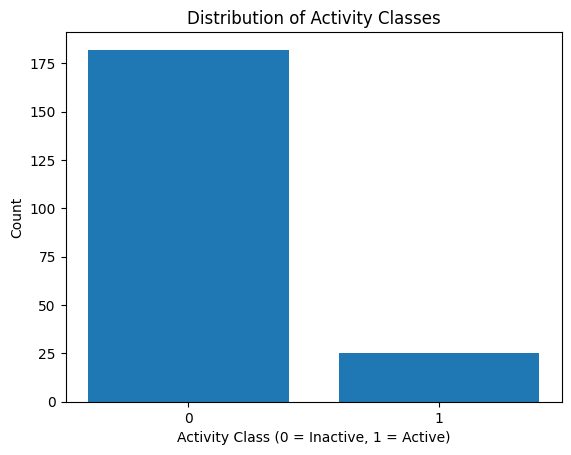

In [7]:
plt.figure()
plt.bar(counts.index.astype(str), counts.values)

plt.xlabel("Activity Class (0 = Inactive, 1 = Active)")
plt.ylabel("Count")
plt.title("Distribution of Activity Classes")

plt.show()

In [ ]:
# Define features and labels
X = data.drop(columns=["Activity", "True_pIC50", "Pred_pIC50"])
y = data["Activity"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData Split Done!")
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Data Split Done!
Training Samples: 165
Testing Samples: 42


In [ ]:
# Initialize models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(probability=True, kernel='rbf', C=2.0, gamma='scale', random_state=42),
    "XGBoost": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
}

result = []
roc_data = {}

In [ ]:
# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n🔹 {name} Model Results 🔹")
    print("Accuracy:", acc)
    print("AUC:", auc)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    result.append({"Model": name, "Accuracy": acc, "AUC": auc})

    # ROC data for plotting later
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, auc)



🔹 Random Forest Model Results 🔹
Accuracy: 0.9285714285714286
AUC: 0.827027027027027
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        37
           1       1.00      0.40      0.57         5

    accuracy                           0.93        42
   macro avg       0.96      0.70      0.77        42
weighted avg       0.93      0.93      0.91        42


🔹 SVM Model Results 🔹
Accuracy: 0.9285714285714286
AUC: 0.9081081081081082
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        37
           1       1.00      0.40      0.57         5

    accuracy                           0.93        42
   macro avg       0.96      0.70      0.77        42
weighted avg       0.93      0.93      0.91        42


🔹 XGBoost Model Results 🔹
Accuracy: 0.9285714285714286
AUC: 0.8918918918918919
Classification Report:
               precision    recall

In [ ]:
# Summary table
results_df = pd.DataFrame(result)
print("\n Model Comparison Summary:\n")
print(results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True))


📊 Model Comparison Summary:

           Model  Accuracy       AUC
0  Random Forest  0.928571  0.827027
1            SVM  0.928571  0.908108
2        XGBoost  0.928571  0.891892


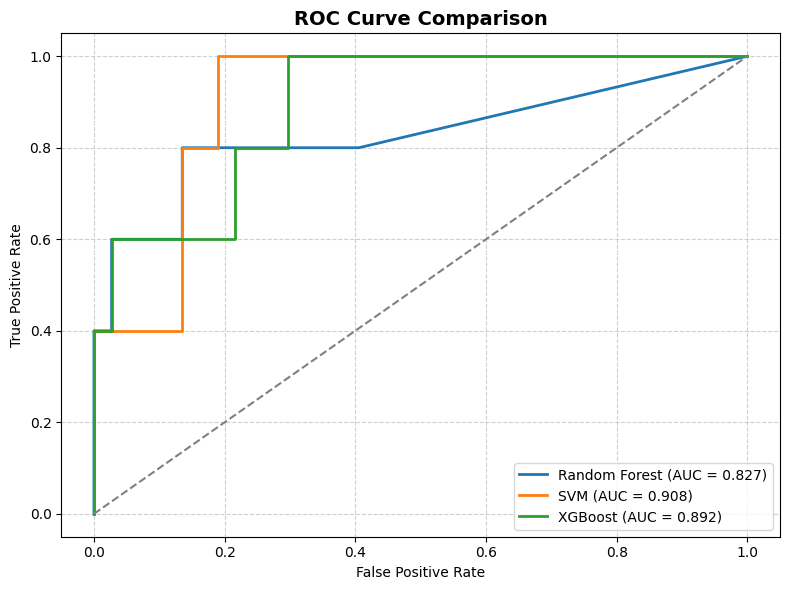

In [ ]:
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_score:.3f})")

# Plot reference line
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')

plt.title("ROC Curve Comparison", fontsize=14, fontweight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# PSO

In [ ]:
!pip install pyswarms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 6.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import pyswarms as ps


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/classification_ready.csv")

X = data.drop(columns=["Activity", "True_pIC50", "Pred_pIC50"])
y = data["Activity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
def fitness_function(particle, X, y):
    n_particles = particle.shape[0]
    scores = np.zeros(n_particles)

    for i in range(n_particles):
        mask = particle[i] > 0.5  # select features
        if np.sum(mask) == 0:
            scores[i] = 1
            continue

        X_selected = X.iloc[:, mask]
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        cv_score = cross_val_score(model, X_selected, y, cv=5, scoring='accuracy').mean()
        scores[i] = 1 - cv_score  # PSO minimizes cost

    return scores

In [ ]:
n_features = X.shape[1]
options = {'c1': 2, 'c2': 2, 'w': 0.9}

optimizer = ps.single.GlobalBestPSO(
    n_particles=20,
    dimensions=n_features,
    options=options
)

cost, pos = optimizer.optimize(fitness_function, iters=30, X=X_train, y=y_train)

selected_features = X.columns[pos > 0.5]
print(f"\nPSO selected {len(selected_features)} features:\n{list(selected_features)}")


2025-11-17 18:59:22,019 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 2, 'c2': 2, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.0848
2025-11-17 19:08:51,991 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.08484848484848473, best pos: [ 1.78759446e-01 -1.52394532e+00  1.58718146e+00  1.10821002e+00
  9.45802680e-01  1.27865060e-01  3.52958420e-02  2.68645583e+00
  1.60706732e+00  2.67584068e-02 -3.90806250e-01 -1.30592135e+00
 -7.57408017e-01 -1.15108149e-01  6.27797003e-01  3.65465465e-01
 -3.20780214e-01  2.82720366e-01  2.52670844e-01  6.97802881e-02
  4.96323531e-01 -5.35969698e-01 -1.28823074e+00  2.00401680e-01
  1.48043079e-01  4.44872269e-02  1.73231019e-01  5.27028788e-01
  1.88078298e+00  3.09536881e-02 -2.82760976e-01 -7.41278888e-02
  5.55735793e-02  2.15180232e-01 -3.84737901e-01 -1.20307471e-01
  2.25802497e-01  7.29401031e-02 -8.15746663e-01  9.05818048e-01
 -1.08181978e+00  9.91156525e-01 


PSO selected 282 features:
['PubchemFP2', 'PubchemFP3', 'PubchemFP4', 'PubchemFP7', 'PubchemFP8', 'PubchemFP14', 'PubchemFP27', 'PubchemFP28', 'PubchemFP39', 'PubchemFP41', 'PubchemFP45', 'PubchemFP47', 'PubchemFP48', 'PubchemFP49', 'PubchemFP52', 'PubchemFP54', 'PubchemFP55', 'PubchemFP57', 'PubchemFP61', 'PubchemFP66', 'PubchemFP79', 'PubchemFP80', 'PubchemFP87', 'PubchemFP94', 'PubchemFP95', 'PubchemFP99', 'PubchemFP100', 'PubchemFP101', 'PubchemFP102', 'PubchemFP103', 'PubchemFP107', 'PubchemFP110', 'PubchemFP116', 'PubchemFP117', 'PubchemFP121', 'PubchemFP124', 'PubchemFP125', 'PubchemFP132', 'PubchemFP134', 'PubchemFP146', 'PubchemFP150', 'PubchemFP152', 'PubchemFP154', 'PubchemFP162', 'PubchemFP163', 'PubchemFP165', 'PubchemFP166', 'PubchemFP171', 'PubchemFP179', 'PubchemFP180', 'PubchemFP181', 'PubchemFP184', 'PubchemFP185', 'PubchemFP187', 'PubchemFP192', 'PubchemFP195', 'PubchemFP196', 'PubchemFP201', 'PubchemFP202', 'PubchemFP204', 'PubchemFP208', 'PubchemFP211', 'PubchemFP

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(probability=True, kernel='rbf', C=1.0, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=42, use_label_encoder=False, eval_metric='logloss'
    )
}

result_PSO = []
roc_data_PSO = {}

In [ ]:
for name, model in models.items():
    model.fit(X_train[selected_features], y_train)
    y_pred = model.predict(X_test[selected_features])
    y_prob = model.predict_proba(X_test[selected_features])[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    result_PSO.append({"Model": name, "Accuracy": acc, "AUC": auc})

    print(f"\n🔹 {name} Results")
    print("Accuracy:", round(acc, 4))
    print("AUC:", round(auc, 4))
    print("Classification Report:\n", classification_report(y_test, y_pred))


    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data_PSO[name] = (fpr, tpr, auc)


🔹 Random Forest Results
Accuracy: 0.9286
AUC: 0.8865
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        37
           1       1.00      0.40      0.57         5

    accuracy                           0.93        42
   macro avg       0.96      0.70      0.77        42
weighted avg       0.93      0.93      0.91        42


🔹 SVM Results
Accuracy: 0.9286
AUC: 0.9
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        37
           1       1.00      0.40      0.57         5

    accuracy                           0.93        42
   macro avg       0.96      0.70      0.77        42
weighted avg       0.93      0.93      0.91        42



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:08:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔹 XGBoost Results
Accuracy: 0.9286
AUC: 0.8865
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        37
           1       1.00      0.40      0.57         5

    accuracy                           0.93        42
   macro avg       0.96      0.70      0.77        42
weighted avg       0.93      0.93      0.91        42



In [ ]:
results_df = pd.DataFrame(result_PSO)
print("\n Model Comparison:")
print(results_df.sort_values(by="AUC", ascending=False).reset_index(drop=True))



📊 Model Comparison:
           Model  Accuracy       AUC
0            SVM  0.928571  0.900000
1  Random Forest  0.928571  0.886486
2        XGBoost  0.928571  0.886486


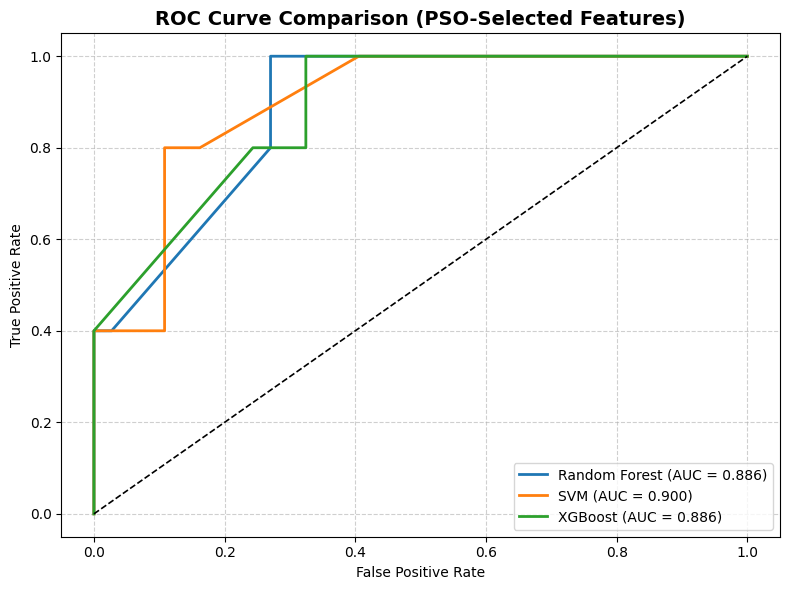

In [ ]:
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, auc_score) in roc_data_PSO.items():
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1.2)
plt.title("ROC Curve Comparison (PSO-Selected Features)", fontsize=14, fontweight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# GWO

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/classification_ready.csv")

X = data.drop(columns=["Activity", "True_pIC50", "Pred_pIC50"])
y = data["Activity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

n_features = X.shape[1]

In [ ]:
def gwo_feature_selection(X, y, n_wolves=15, max_iter=20):
    dim = X.shape[1]
    alpha_pos = np.zeros(dim)
    beta_pos = np.zeros(dim)
    delta_pos = np.zeros(dim)
    alpha_score = float("inf")
    beta_score = float("inf")
    delta_score = float("inf")

    positions = np.random.randint(0, 2, (n_wolves, dim))
    convergence_curve = []

    def fitness(position):
        mask = position > 0.5
        if np.sum(mask) == 0:
            return 1.0
        X_subset = X.iloc[:, mask]
        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        score = cross_val_score(clf, X_subset, y, cv=5, scoring="accuracy").mean()
        return 1 - score  # minimize cost

    for t in range(max_iter):
        a = 2 - t * (2 / max_iter)
        for i in range(n_wolves):
            fitness_val = fitness(positions[i])
            if fitness_val < alpha_score:
                alpha_score, alpha_pos = fitness_val, positions[i].copy()
            elif fitness_val < beta_score:
                beta_score, beta_pos = fitness_val, positions[i].copy()
            elif fitness_val < delta_score:
                delta_score, delta_pos = fitness_val, positions[i].copy()

        for i in range(n_wolves):
            for j in range(dim):
                r1, r2 = np.random.rand(), np.random.rand()
                A1, C1 = 2*a*r1 - a, 2*r2
                D_alpha = abs(C1*alpha_pos[j] - positions[i][j])
                X1 = alpha_pos[j] - A1*D_alpha

                r1, r2 = np.random.rand(), np.random.rand()
                A2, C2 = 2*a*r1 - a, 2*r2
                D_beta = abs(C2*beta_pos[j] - positions[i][j])
                X2 = beta_pos[j] - A2*D_beta

                r1, r2 = np.random.rand(), np.random.rand()
                A3, C3 = 2*a*r1 - a, 2*r2
                D_delta = abs(C3*delta_pos[j] - positions[i][j])
                X3 = delta_pos[j] - A3*D_delta

                positions[i][j] = (X1 + X2 + X3) / 3

            # Binary transformation
            sigmoid = 1 / (1 + np.exp(-10*(positions[i]-0.5)))
            positions[i] = np.where(sigmoid > np.random.rand(dim), 1, 0)

        convergence_curve.append(alpha_score)
        print(f"Iteration {t+1}/{max_iter} | Best Fitness: {round(alpha_score, 4)}")

    selected = np.where(alpha_pos > 0.5)[0]
    return X.columns[selected], convergence_curve

In [ ]:
#  Run GWO

selected_features, convergence_curve = gwo_feature_selection(X_train, y_train, n_wolves=15, max_iter=20)
print(f"\nGWO selected {len(selected_features)} features:\n{list(selected_features)}")

Iteration 1/20 | Best Fitness: 0.0909
Iteration 2/20 | Best Fitness: 0.0848
Iteration 3/20 | Best Fitness: 0.0727
Iteration 4/20 | Best Fitness: 0.0727
Iteration 5/20 | Best Fitness: 0.0727
Iteration 6/20 | Best Fitness: 0.0727
Iteration 7/20 | Best Fitness: 0.0727
Iteration 8/20 | Best Fitness: 0.0727
Iteration 9/20 | Best Fitness: 0.0727
Iteration 10/20 | Best Fitness: 0.0727
Iteration 11/20 | Best Fitness: 0.0727
Iteration 12/20 | Best Fitness: 0.0727
Iteration 13/20 | Best Fitness: 0.0727
Iteration 14/20 | Best Fitness: 0.0727
Iteration 15/20 | Best Fitness: 0.0727
Iteration 16/20 | Best Fitness: 0.0727
Iteration 17/20 | Best Fitness: 0.0727
Iteration 18/20 | Best Fitness: 0.0727
Iteration 19/20 | Best Fitness: 0.0727
Iteration 20/20 | Best Fitness: 0.0727

GWO selected 142 features:
['PubchemFP0', 'PubchemFP3', 'PubchemFP25', 'PubchemFP39', 'PubchemFP44', 'PubchemFP49', 'PubchemFP60', 'PubchemFP62', 'PubchemFP66', 'PubchemFP67', 'PubchemFP71', 'PubchemFP81', 'PubchemFP82', 'Pubche

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128058 (\N{WOLF FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


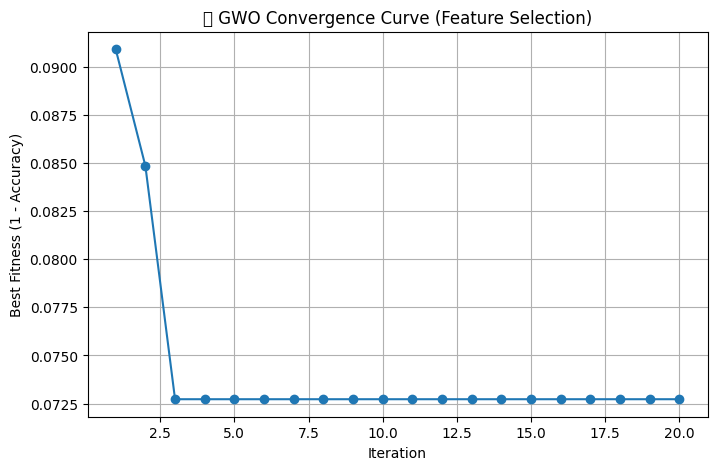

In [ ]:
# Plot Convergence Curve

plt.figure(figsize=(8,5))
plt.plot(range(1, len(convergence_curve)+1), convergence_curve, marker='o')
plt.title("GWO Convergence Curve (Feature Selection)")
plt.xlabel("Iteration")
plt.ylabel("Best Fitness (1 - Accuracy)")
plt.grid(True)
plt.show()

In [ ]:
# Train and Evaluate Models on Selected Features
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(probability=True, kernel="rbf", C=1.0, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, use_label_encoder=False, eval_metric="logloss"
    ),
}
results_GWO = []
roc_data_GWO = {}

In [ ]:
results_GWO = []
roc_data_GWO = {}

for name, model in models.items():
    model.fit(X_train[selected_features], y_train)
    y_pred = model.predict(X_test[selected_features])
    y_prob = model.predict_proba(X_test[selected_features])[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # Compute ROC curve points
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data_GWO[name] = (fpr, tpr, auc)

    results_GWO.append({"Model": name, "Accuracy": acc, "AUC": auc})

    print(f"\n🔹 {name} Results")
    print("Accuracy:", round(acc, 4))
    print("AUC:", round(auc, 4))
    print("Classification Report:\n", classification_report(y_test, y_pred))



🔹 Random Forest Results
Accuracy: 0.9524
AUC: 0.8135
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        37
           1       1.00      0.60      0.75         5

    accuracy                           0.95        42
   macro avg       0.97      0.80      0.86        42
weighted avg       0.95      0.95      0.95        42


🔹 SVM Results
Accuracy: 0.9286
AUC: 0.8568
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        37
           1       1.00      0.40      0.57         5

    accuracy                           0.93        42
   macro avg       0.96      0.70      0.77        42
weighted avg       0.93      0.93      0.91        42


🔹 XGBoost Results
Accuracy: 0.9286
AUC: 0.8568
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        37
           1       

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:12:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
results_df = pd.DataFrame(results_GWO)
print("\n Model Comparison:")
print(results_df.sort_values(by="AUC", ascending=False).reset_index(drop=True))



 Model Comparison:
           Model  Accuracy       AUC
0            SVM  0.928571  0.856757
1        XGBoost  0.928571  0.856757
2  Random Forest  0.952381  0.813514


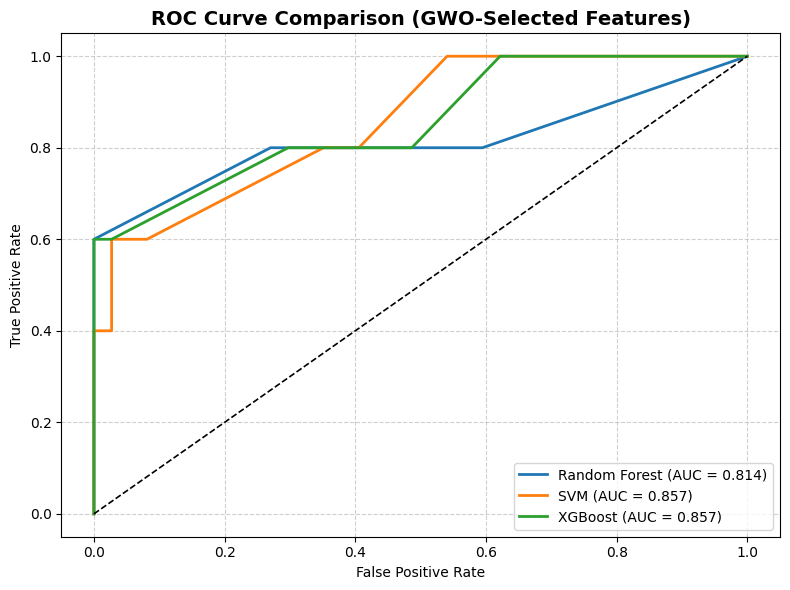

In [ ]:
# Plot ROC Curves
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, auc_score) in roc_data_GWO.items():
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1.2)
plt.title("ROC Curve Comparison (GWO-Selected Features)", fontsize=14, fontweight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# PSO + GWO

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/classification_ready.csv")

X = data.drop(columns=["Activity", "True_pIC50", "Pred_pIC50"])
y = data["Activity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

n_features = X.shape[1]

In [ ]:
def gwopso_feature_selection(X, y, n_agents=20, max_iter=25, alpha_weight=0.7):
    dim = X.shape[1]
    positions = np.random.randint(0, 2, (n_agents, dim))  # binary feature masks
    velocities = np.random.uniform(-1, 1, (n_agents, dim))

    alpha_pos = np.zeros(dim)
    beta_pos = np.zeros(dim)
    delta_pos = np.zeros(dim)
    alpha_score, beta_score, delta_score = float("inf"), float("inf"), float("inf")

    convergence_curve = []

    def fitness(position):
        mask = position > 0.5
        if np.sum(mask) == 0:
            return 1.0
        X_subset = X.iloc[:, mask]
        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        score = cross_val_score(clf, X_subset, y, cv=5, scoring="accuracy").mean()
        return 1 - score  # minimize cost

    for t in range(max_iter):
        a = 2 - t * (2 / max_iter)

        for i in range(n_agents):
            fitness_val = fitness(positions[i])
            if fitness_val < alpha_score:
                alpha_score, alpha_pos = fitness_val, positions[i].copy()
            elif fitness_val < beta_score:
                beta_score, beta_pos = fitness_val, positions[i].copy()
            elif fitness_val < delta_score:
                delta_score, delta_pos = fitness_val, positions[i].copy()

        for i in range(n_agents):
            for j in range(dim):
                r1, r2 = np.random.rand(), np.random.rand()
                A1, C1 = 2*a*r1 - a, 2*r2
                D_alpha = abs(C1*alpha_pos[j] - positions[i][j])
                X1 = alpha_pos[j] - A1*D_alpha

                r1, r2 = np.random.rand(), np.random.rand()
                A2, C2 = 2*a*r1 - a, 2*r2
                D_beta = abs(C2*beta_pos[j] - positions[i][j])
                X2 = beta_pos[j] - A2*D_beta

                r1, r2 = np.random.rand(), np.random.rand()
                A3, C3 = 2*a*r1 - a, 2*r2
                D_delta = abs(C3*delta_pos[j] - positions[i][j])
                X3 = delta_pos[j] - A3*D_delta

                gwo_update = (X1 + X2 + X3) / 3

                # PSO component
                r1, r2 = np.random.rand(), np.random.rand()
                velocities[i][j] = alpha_weight * velocities[i][j] + r1*(alpha_pos[j] - positions[i][j]) + r2*(beta_pos[j] - positions[i][j])
                pso_update = positions[i][j] + velocities[i][j]

                # Combine GWO + PSO
                combined = (alpha_weight * gwo_update) + ((1 - alpha_weight) * pso_update)
                positions[i][j] = np.clip(combined, 0, 1)

            # Binary transfer function
            sigmoid = 1 / (1 + np.exp(-10*(positions[i]-0.5)))
            positions[i] = np.where(sigmoid > np.random.rand(dim), 1, 0)

        convergence_curve.append(alpha_score)
        print(f"Iteration {t+1}/{max_iter} | Best Fitness: {round(alpha_score, 4)}")

    selected = np.where(alpha_pos > 0.5)[0]
    return X.columns[selected], convergence_curve



In [ ]:
selected_features, convergence_curve = gwopso_feature_selection(X_train, y_train, n_agents=20, max_iter=25)
print(f"\nGWOPSO selected {len(selected_features)} features:\n{list(selected_features)}")

Iteration 1/25 | Best Fitness: 0.0909
Iteration 2/25 | Best Fitness: 0.0848
Iteration 3/25 | Best Fitness: 0.0848
Iteration 4/25 | Best Fitness: 0.0848
Iteration 5/25 | Best Fitness: 0.0848
Iteration 6/25 | Best Fitness: 0.0848
Iteration 7/25 | Best Fitness: 0.0848
Iteration 8/25 | Best Fitness: 0.0848
Iteration 9/25 | Best Fitness: 0.0848
Iteration 10/25 | Best Fitness: 0.0848
Iteration 11/25 | Best Fitness: 0.0848
Iteration 12/25 | Best Fitness: 0.0848
Iteration 13/25 | Best Fitness: 0.0848
Iteration 14/25 | Best Fitness: 0.0848
Iteration 15/25 | Best Fitness: 0.0848
Iteration 16/25 | Best Fitness: 0.0848
Iteration 17/25 | Best Fitness: 0.0848
Iteration 18/25 | Best Fitness: 0.0848
Iteration 19/25 | Best Fitness: 0.0848
Iteration 20/25 | Best Fitness: 0.0848
Iteration 21/25 | Best Fitness: 0.0848
Iteration 22/25 | Best Fitness: 0.0848
Iteration 23/25 | Best Fitness: 0.0848
Iteration 24/25 | Best Fitness: 0.0848
Iteration 25/25 | Best Fitness: 0.0848

GWOPSO selected 140 features:
['P

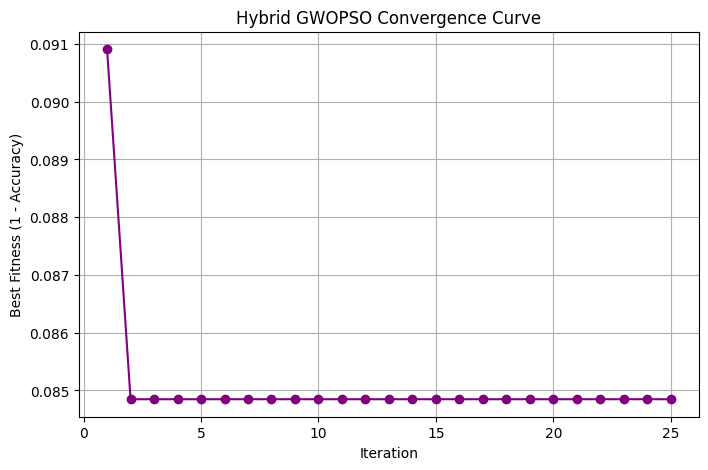

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(convergence_curve)+1), convergence_curve, marker='o', color='purple')
plt.title("Hybrid GWOPSO Convergence Curve")
plt.xlabel("Iteration")
plt.ylabel("Best Fitness (1 - Accuracy)")
plt.grid(True)
plt.show()

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(probability=True, kernel="rbf", C=1.0, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, use_label_encoder=False, eval_metric="logloss"
    ),
}

results_GWOPSO = []
roc_data_GWOPSO = {}

In [ ]:
for name, model in models.items():
    model.fit(X_train[selected_features], y_train)
    y_pred = model.predict(X_test[selected_features])
    y_prob = model.predict_proba(X_test[selected_features])[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data_GWOPSO[name] = (fpr, tpr, auc)
    results_GWOPSO.append({"Model": name, "Accuracy": acc, "AUC": auc})

    print(f"\n🔹 {name} Results")
    print("Accuracy:", round(acc, 4))
    print("AUC:", round(auc, 4))
    print("Classification Report:\n", classification_report(y_test, y_pred))


🔹 Random Forest Results
Accuracy: 0.9286
AUC: 0.8297
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        37
           1       1.00      0.40      0.57         5

    accuracy                           0.93        42
   macro avg       0.96      0.70      0.77        42
weighted avg       0.93      0.93      0.91        42


🔹 SVM Results
Accuracy: 0.9286
AUC: 0.7649
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        37
           1       1.00      0.40      0.57         5

    accuracy                           0.93        42
   macro avg       0.96      0.70      0.77        42
weighted avg       0.93      0.93      0.91        42



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:19:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔹 XGBoost Results
Accuracy: 0.9286
AUC: 0.8081
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        37
           1       1.00      0.40      0.57         5

    accuracy                           0.93        42
   macro avg       0.96      0.70      0.77        42
weighted avg       0.93      0.93      0.91        42



In [ ]:
results_df = pd.DataFrame(results_GWOPSO)
print("\n Model Comparison:")
print(results_df.sort_values(by="AUC", ascending=False).reset_index(drop=True))


 Model Comparison:
           Model  Accuracy       AUC
0  Random Forest  0.928571  0.829730
1        XGBoost  0.928571  0.808108
2            SVM  0.928571  0.764865


In [ ]:
best_row = results_df.sort_values(by="AUC", ascending=False).iloc[0]
best_model_name = best_row["Model"]
best_model = models[best_model_name]

# fit best model on training data
best_model.fit(X_train[selected_features], y_train)

y_pred_best = best_model.predict(X_test[selected_features])
y_prob_best = best_model.predict_proba(X_test[selected_features])[:, 1]


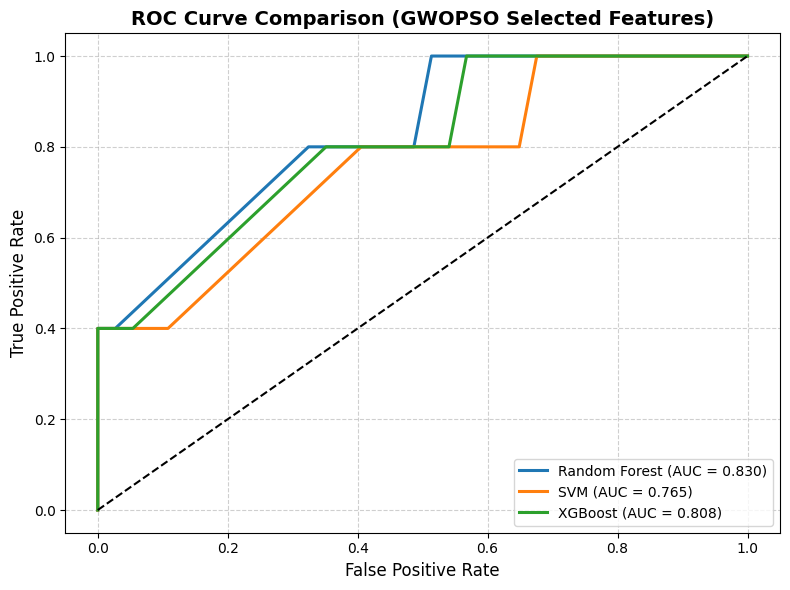

In [ ]:
plt.figure(figsize=(8,6))

for name, (fpr, tpr, auc_score) in roc_data_GWOPSO.items():
    plt.plot(
        fpr, tpr, lw=2.2,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

# Diagonal baseline
plt.plot([0,1], [0,1], 'k--', lw=1.5)

plt.title("ROC Curve Comparison (GWOPSO Selected Features)", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


Text(0, 0.5, 'AUC Score')

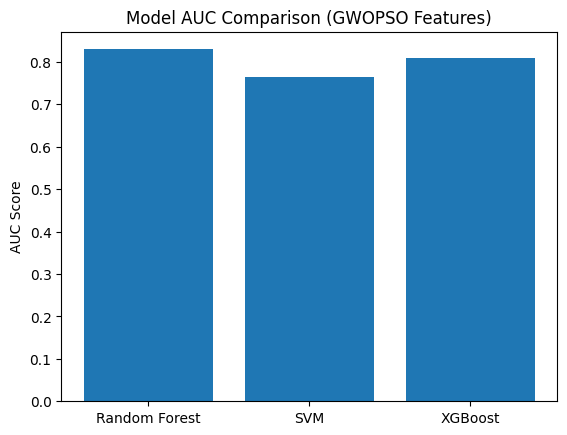

In [ ]:
plt.bar(results_df["Model"], results_df["AUC"])
plt.title("Model AUC Comparison (GWOPSO Features)")
plt.ylabel("AUC Score")


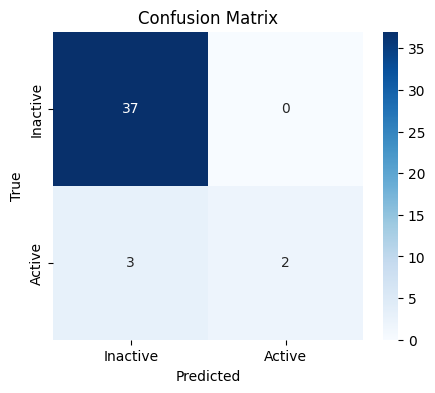

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Inactive", "Active"],
            yticklabels=["Inactive", "Active"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


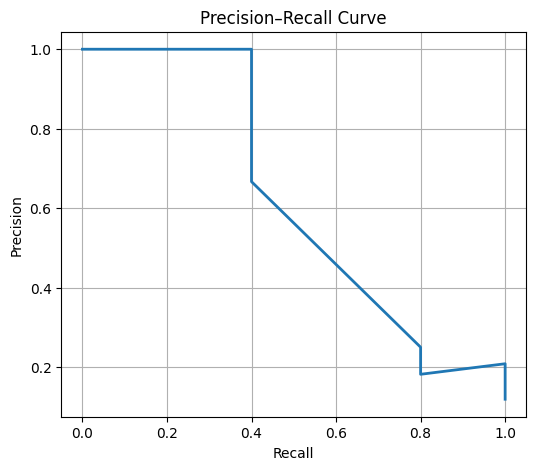

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_best)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, lw=2)
plt.title("Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()


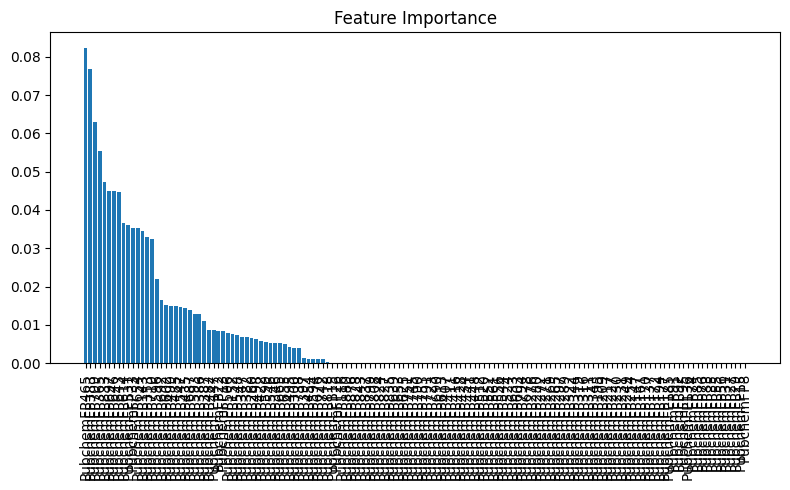

In [ ]:
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X_train[selected_features].columns[indices], rotation=90)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()


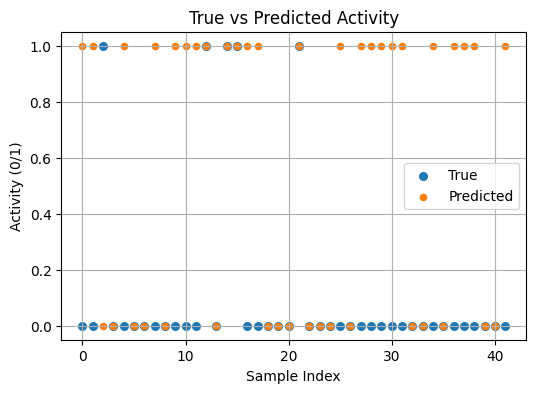

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(range(len(y_test)), y_test, label="True", s=30)
plt.scatter(range(len(y_pred)), y_pred, label="Predicted", s=20)
plt.title("True vs Predicted Activity")
plt.xlabel("Sample Index")
plt.ylabel("Activity (0/1)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96        37
           1       1.00      0.40      0.57         5

    accuracy                           0.93        42
   macro avg       0.96      0.70      0.77        42
weighted avg       0.93      0.93      0.91        42



In [ ]:
import joblib
import os
import pandas as pd

save_dir = "/content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/saved_models"
os.makedirs(save_dir, exist_ok=True)

# Identify best model based on highest AUC
best_model_row = results_df.sort_values(by="AUC", ascending=False).iloc[0]
best_model_name = best_model_row["Model"]
best_model = models[best_model_name]

# Retrain best model before saving
best_model.fit(X_train[selected_features], y_train)

# Save model
model_filename = os.path.join(save_dir, f"best_model_{best_model_name.replace(' ', '_')}.pkl")
joblib.dump(best_model, model_filename)

# Save selected features as .pkl (RECOMMENDED for Streamlit)
features_filename = os.path.join(save_dir, "selected_features.pkl")
joblib.dump(list(selected_features), features_filename)

print(f"\nBest model '{best_model_name}' saved as: {model_filename}")
print(f"Selected features saved as: {features_filename}")
print(f"Best Model Summary: Accuracy = {best_model_row['Accuracy']:.4f}, AUC = {best_model_row['AUC']:.4f}")



Best model 'Random Forest' saved as: /content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/saved_models/best_model_Random_Forest.pkl
Selected features saved as: /content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/saved_models/selected_features.pkl
Best Model Summary: Accuracy = 0.9286, AUC = 0.8297
